In [ ]:
!pip install gdown

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import gdown

In [ ]:
dataset_rm_1_url = 'https://drive.google.com/uc?id=1GtkTgeHmKo8JvyBtqJURQWU-OgvokwZ5'
dataset_rm_qris_url = 'https://drive.google.com/uc?id=1H5_gkp-PW_0FXSTSCCZVhds4ZzlSU3nt'
dataset_rm_bifast_url = 'https://drive.google.com/uc?id=1wGpVCnXQpUBIZTgljNwOc_8LJ90QHI2n'

gdown.download(dataset_rm_1_url, 'DatasetRM-1.csv', quiet=False)
gdown.download(dataset_rm_qris_url, 'DatasetRM-QRIS.csv', quiet=False)
gdown.download(dataset_rm_bifast_url, 'DatasetRM-BI-FAST.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1GtkTgeHmKo8JvyBtqJURQWU-OgvokwZ5
To: /content/DatasetRM-1.csv
100%|██████████| 10.9k/10.9k [00:00<00:00, 15.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1H5_gkp-PW_0FXSTSCCZVhds4ZzlSU3nt
To: /content/DatasetRM-QRIS.csv
100%|██████████| 258/258 [00:00<00:00, 94.7kB/s]
Downloading...
From: https://drive.google.com/uc?id=1wGpVCnXQpUBIZTgljNwOc_8LJ90QHI2n
To: /content/DatasetRM-BI-FAST.csv
100%|██████████| 227/227 [00:00<00:00, 547kB/s]


'DatasetRM-BI-FAST.csv'

In [ ]:
df = pd.read_csv("DatasetRM-1.csv", decimal = ',', thousands = '.')
df.head()

,Bank,LCR,CAR,LDR,NIM,ROA,BOPO,NPL,Total Assets(dlm jutaan),Year,Kuartil
0,BCA,3.1093,0.2976,0.7675,0.0573,0.0475,0.4156,0.0171,1.586829e+09,2025,4
1,BCA,3.0694,0.2994,0.7559,0.0576,0.0487,0.4085,0.0210,1.538502e+09,2025,3
2,BCA,2.9355,0.2839,0.7804,0.0578,0.0499,0.4046,0.0217,1.504119e+09,2025,2
3,BCA,3.0690,0.2663,0.7606,0.0577,0.0520,0.3911,0.0204,1.533763e+09,2025,1
4,BCA,3.2940,0.2936,0.7844,0.0583,0.0486,0.4167,0.0178,1.449301e+09,2024,4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Bank                      120 non-null    object 
 1   LCR                       120 non-null    float64
 2   CAR                       118 non-null    float64
 3   LDR                       118 non-null    float64
 4   NIM                       118 non-null    float64
 5   ROA                       118 non-null    float64
 6   BOPO                      118 non-null    float64
 7   NPL                       118 non-null    float64
 8   Total Assets(dlm jutaan)  116 non-null    float64
 9   Year                      120 non-null    int64  
 10  Kuartil                   120 non-null    int64  
dtypes: float64(8), int64(2), object(1)
memory usage: 10.4+ KB


In [ ]:
df_qris = pd.read_csv("DatasetRM-QRIS.csv", decimal = ',', thousands = '.')
df_qris.head()

,Tahun,Volume_Transaksi,Nominal(Rp)
0,2025,13660000000,1.150000e+15
1,2024,6240000000,6.599300e+14
2,2023,2140000000,2.260000e+14
3,2022,1000000000,9.998000e+13
4,2021,374690000,2.763000e+13


In [ ]:
df_BIFAST = pd.read_csv("DatasetRM-BI-FAST.csv", decimal = ',', thousands = '.')
df_BIFAST.head()

,BI-FAST,Volume_Transaksi,Nominal(Rp)
0,2025,4.770000e+09,1.199500e+13
1,2024,3.400000e+09,8.900000e+12
2,2023,2.410000e+09,6.818000e+12
3,2022,4.140000e+08,1.431000e+12
4,2021,3.200000e+05,1.700000e+12


In [ ]:
threshold = df["LCR"].quantile(0.25)
df["LCR_Flag"] = np.where(df["LCR"] > threshold, 1, 0)

df["Log_Total_Aset"] = np.log(df["Total Assets(dlm jutaan)"] + 1)

df_qris_temp = df_qris.rename(columns={'Tahun': 'Year', 'Volume_Transaksi': 'QRIS_Volume_Transaksi', 'Nominal(Rp)': 'QRIS_Nominal'})
df_bifast_temp = df_BIFAST.rename(columns={'BI-FAST': 'Year', 'Volume_Transaksi': 'BIFAST_Volume_Transaksi', 'Nominal(Rp)': 'BIFast_Nominal'})

df = pd.merge(df, df_qris_temp[['Year', 'QRIS_Volume_Transaksi', 'QRIS_Nominal']], on='Year', how='left')
df = pd.merge(df, df_bifast_temp[['Year', 'BIFAST_Volume_Transaksi', 'BIFast_Nominal']], on='Year', how='left')

df["Digital_Volume_Total"] = df['QRIS_Volume_Transaksi'].fillna(0) + df['BIFAST_Volume_Transaksi'].fillna(0)
df["Digital_Nominal_Total"] = df['QRIS_Nominal'].fillna(0) + df['BIFast_Nominal'].fillna(0)

df[['Year', 'QRIS_Volume_Transaksi', 'BIFAST_Volume_Transaksi', 'Digital_Volume_Total', 'Digital_Nominal_Total']].head()

,Year,QRIS_Volume_Transaksi,BIFAST_Volume_Transaksi,Digital_Volume_Total,Digital_Nominal_Total
0,2025,13660000000,4.770000e+09,1.843000e+10,1.161995e+15
1,2025,13660000000,4.770000e+09,1.843000e+10,1.161995e+15
2,2025,13660000000,4.770000e+09,1.843000e+10,1.161995e+15
3,2025,13660000000,4.770000e+09,1.843000e+10,1.161995e+15
4,2024,6240000000,3.400000e+09,9.640000e+09,6.688300e+14


In [ ]:
feature_cols = [
    "CAR",
    "LDR",
    "NIM",
    "ROA",
    "BOPO",
    "NPL",
    "Log_Total_Aset",
    "Digital_Volume_Total",
    "Digital_Nominal_Total"
]

X = df[feature_cols]
y = df["LCR_Flag"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
logistic_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_pipeline.fit(X_train, y_train)

y_pred_lr = logistic_pipeline.predict(X_test)
y_proba_lr = logistic_pipeline.predict_proba(X_test)[:, 1]

In [ ]:
scale_pos_weight = (
    (y_train == 0).sum() / max((y_train == 1).sum(), 1)
)

xgb_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42
    ))
])

xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test)
y_proba_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]


Logistic Regression
Accuracy : 0.9166666666666666
Precision: 0.9444444444444444
Recall   : 0.9444444444444444
F1-Score : 0.9444444444444444
AUC-ROC  : 0.9907407407407407

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83         6
           1       0.94      0.94      0.94        18

    accuracy                           0.92        24
   macro avg       0.89      0.89      0.89        24
weighted avg       0.92      0.92      0.92        24


Confusion Matrix:
[[ 5  1]
 [ 1 17]]


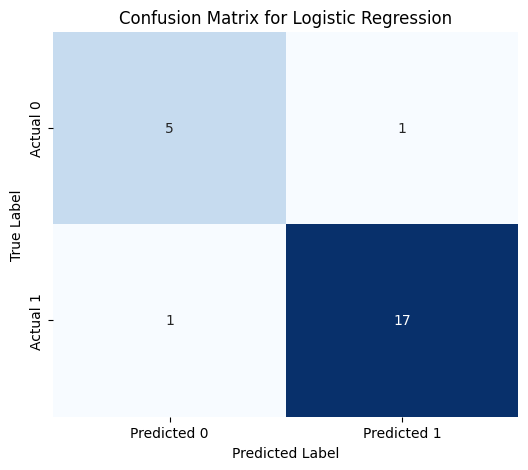


XGBoost
Accuracy : 0.9583333333333334
Precision: 0.9473684210526315
Recall   : 1.0
F1-Score : 0.972972972972973
AUC-ROC  : 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       0.95      1.00      0.97        18

    accuracy                           0.96        24
   macro avg       0.97      0.92      0.94        24
weighted avg       0.96      0.96      0.96        24


Confusion Matrix:
[[ 5  1]
 [ 0 18]]


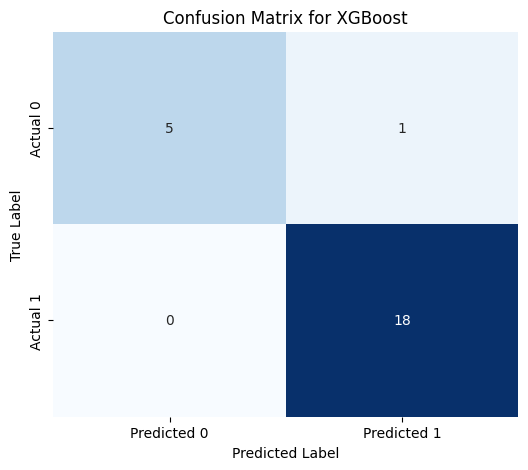

In [ ]:
def evaluate_model(name, y_true, y_pred, y_proba):
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1-Score :", f1_score(y_true, y_pred))
    print("AUC-ROC  :", roc_auc_score(y_true, y_proba))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()


evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_lr,
    y_proba_lr
)

evaluate_model(
    "XGBoost",
    y_test,
    y_pred_xgb,
    y_proba_xgb
)

<Figure size 800x600 with 0 Axes>

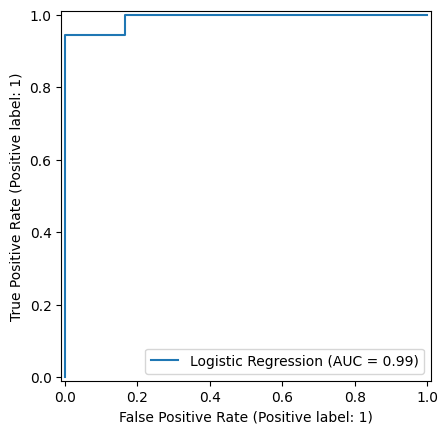

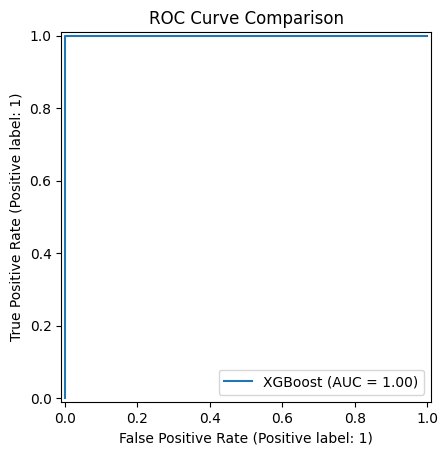

In [ ]:
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test, y_proba_lr, name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test, y_proba_xgb, name="XGBoost"
)

plt.title("ROC Curve Comparison")
plt.show()

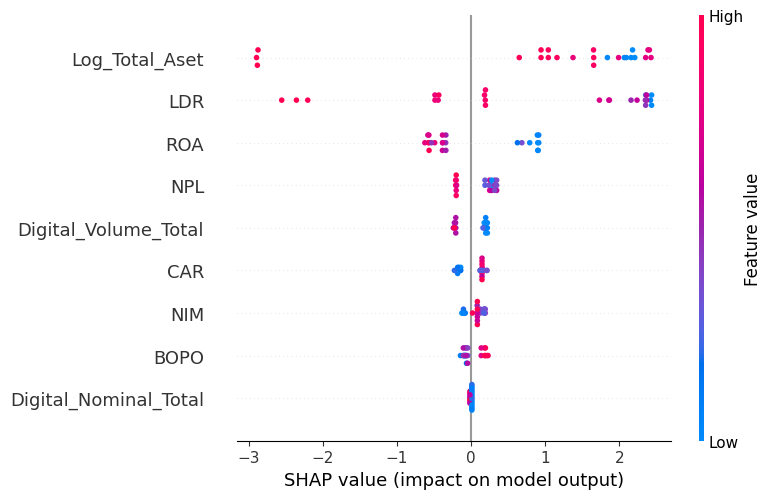

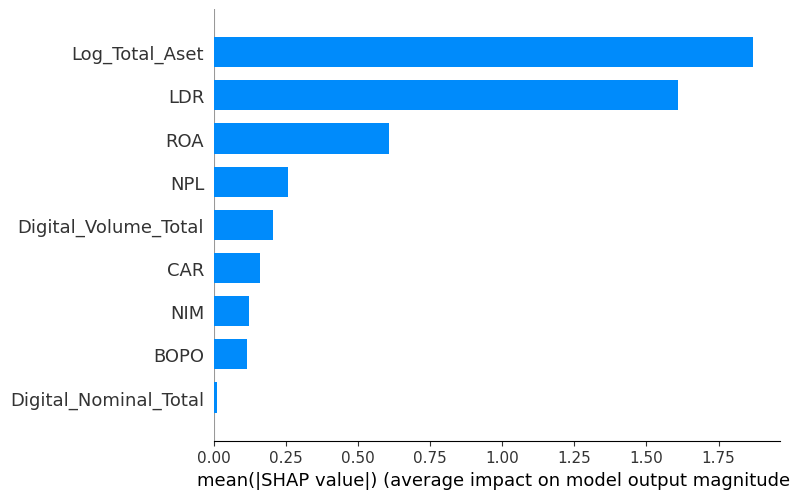

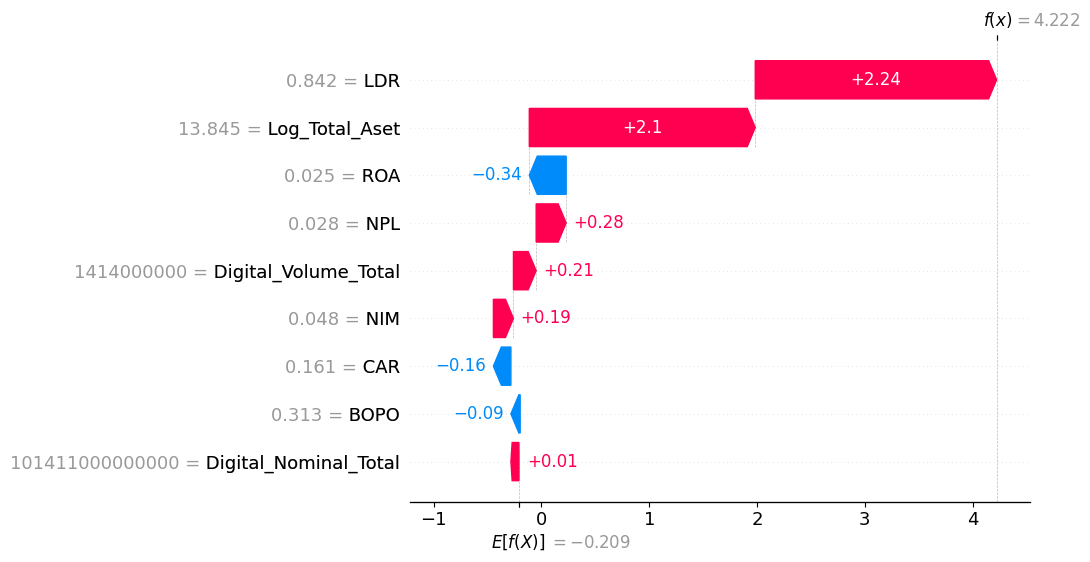

In [ ]:
imputer = xgb_pipeline.named_steps["imputer"]
xgb_model = xgb_pipeline.named_steps["model"]

X_train_imp = imputer.transform(X_train)
X_test_imp = imputer.transform(X_test)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_imp)

shap.summary_plot(
    shap_values,
    X_test_imp,
    feature_names=feature_cols
)

shap.summary_plot(
    shap_values,
    X_test_imp,
    feature_names=feature_cols,
    plot_type="bar"
)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test_imp[0],
        feature_names=feature_cols
    )
)


Top Feature Importances:
                 Feature  Importance
6         Log_Total_Aset    0.276893
1                    LDR    0.208838
3                    ROA    0.117501
2                    NIM    0.096537
4                   BOPO    0.073316
0                    CAR    0.070744
7   Digital_Volume_Total    0.068076
8  Digital_Nominal_Total    0.046870
5                    NPL    0.041224


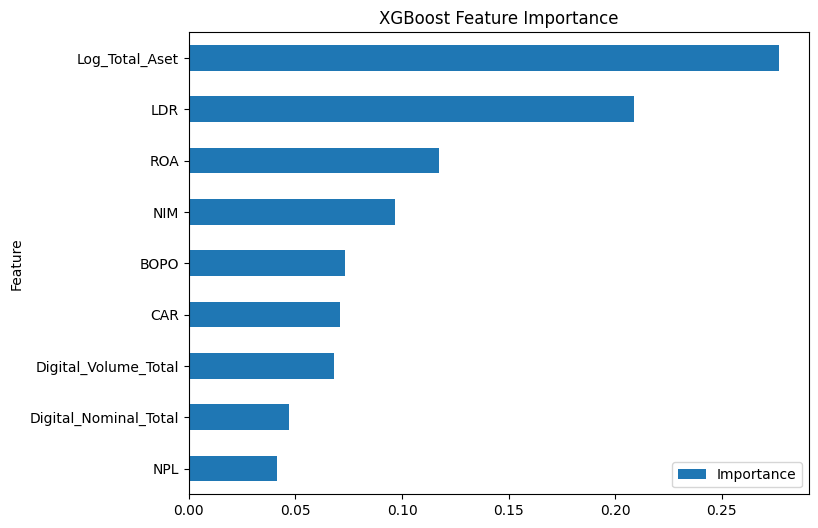

In [ ]:
importances = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nTop Feature Importances:")
print(importances)

importances.head(15).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(8, 6)
)
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.show()

## Tradisional model

In [ ]:
feature_cols_B = [
    "CAR",
    "LDR",
    "NIM",
    "ROA",
    "BOPO",
    "NPL",
    "Log_Total_Aset",
]

X_B = df[feature_cols_B]
y_B = df["LCR_Flag"]

X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B,
    y_B,
    test_size=0.2,
    random_state=42,
    stratify=y_B
)


XGBoost (Reduced Features)
Accuracy : 0.9583333333333334
Precision: 0.9473684210526315
Recall   : 1.0
F1-Score : 0.972972972972973
AUC-ROC  : 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       0.95      1.00      0.97        18

    accuracy                           0.96        24
   macro avg       0.97      0.92      0.94        24
weighted avg       0.96      0.96      0.96        24


Confusion Matrix:
[[ 5  1]
 [ 0 18]]


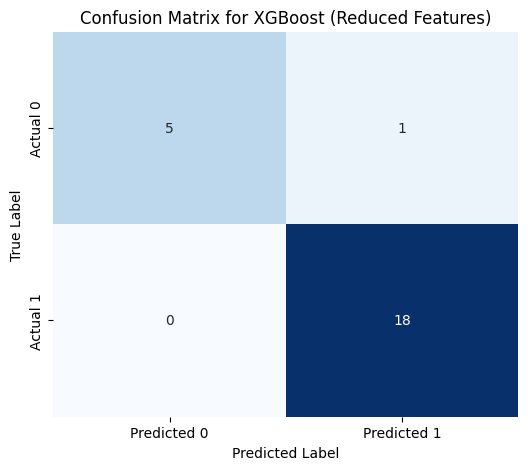

In [ ]:
scale_pos_weight_B = (
    (y_train_B == 0).sum() / max((y_train_B == 1).sum(), 1)
)

xgb_pipeline_B = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight_B,
        random_state=42
    ))
])

xgb_pipeline_B.fit(X_train_B, y_train_B)

y_pred_xgb_B = xgb_pipeline_B.predict(X_test_B)
y_proba_xgb_B = xgb_pipeline_B.predict_proba(X_test_B)[:, 1]

evaluate_model(
    "XGBoost (Reduced Features)",
    y_test_B,
    y_pred_xgb_B,
    y_proba_xgb_B
)

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores_lr = cross_val_score(
    logistic_pipeline,
    X,
    y,
    cv=cv,
    scoring="f1"
)

print("Logistic Regression")
print(scores_lr)
print("Mean:", scores_lr.mean())
print("Std:", scores_lr.std())

scores_xgb = cross_val_score(
    xgb_pipeline,
    X,
    y,
    cv=cv,
    scoring="f1"
)

print("XGBoost")
print(scores_xgb)
print("Mean:", scores_xgb.mean())
print("Std:", scores_xgb.std())

Logistic Regression
[0.97297297 1.         0.94444444 0.94117647 0.97142857]
Mean: 0.9660044918868449
Std: 0.021517161647006643
XGBoost
[0.97297297 0.97142857 0.94444444 0.94117647 0.90909091]
Mean: 0.9478226737050267
Std: 0.023432925551590152


<Figure size 800x600 with 0 Axes>

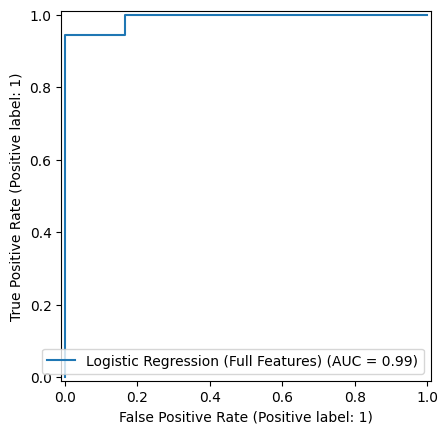

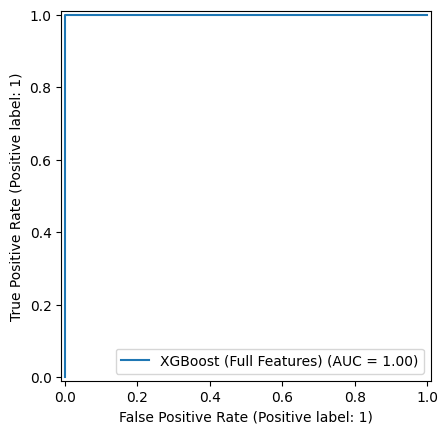

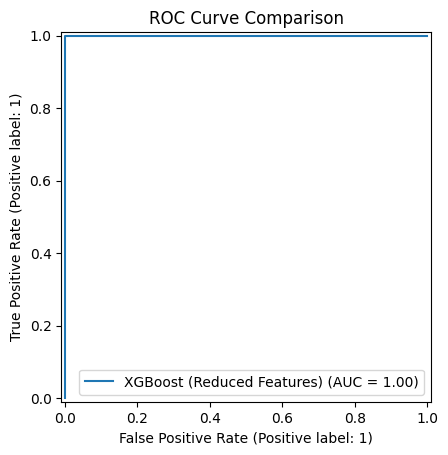

In [ ]:
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test, y_proba_lr, name="Logistic Regression (Full Features)"
)

RocCurveDisplay.from_predictions(
    y_test, y_proba_xgb, name="XGBoost (Full Features)"
)

RocCurveDisplay.from_predictions(
    y_test_B, y_proba_xgb_B, name="XGBoost (Reduced Features)"
)

plt.title("ROC Curve Comparison")
plt.show()


Top Feature Importances (Reduced Features):
          Feature  Importance
6  Log_Total_Aset    0.298003
2             NIM    0.197409
1             LDR    0.176703
3             ROA    0.119035
0             CAR    0.081032
4            BOPO    0.074869
5             NPL    0.052949


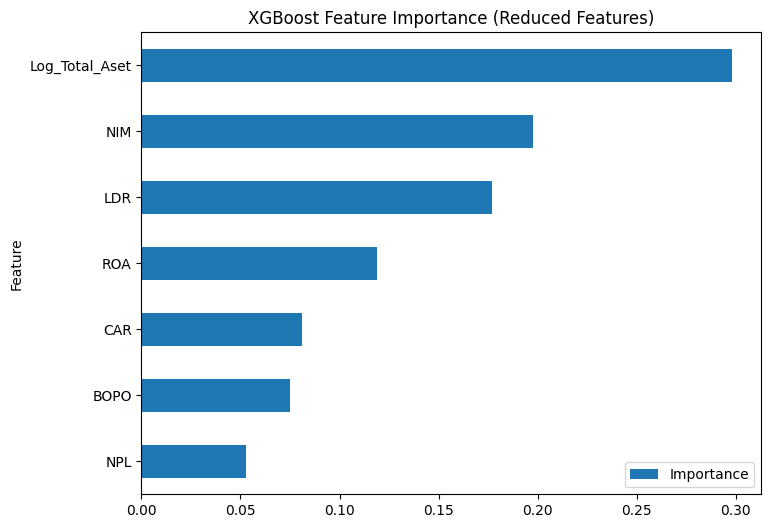

In [ ]:
xgb_model_B = xgb_pipeline_B.named_steps["model"]

importances_B = pd.DataFrame({
    "Feature": feature_cols_B,
    "Importance": xgb_model_B.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nTop Feature Importances (Reduced Features):")
print(importances_B)

importances_B.head(15).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(8, 6)
)
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance (Reduced Features)")
plt.show()

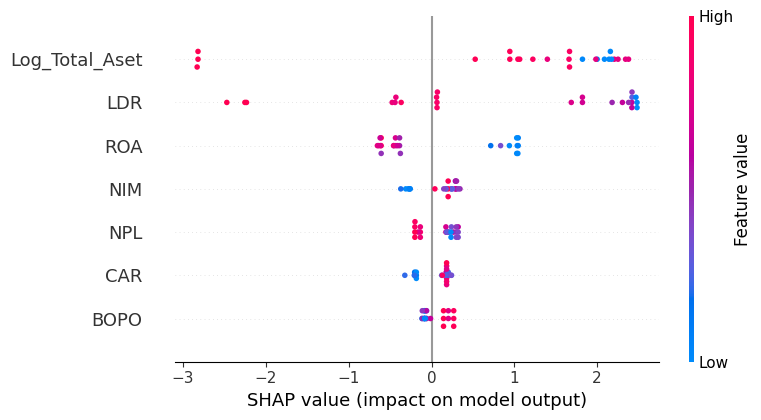

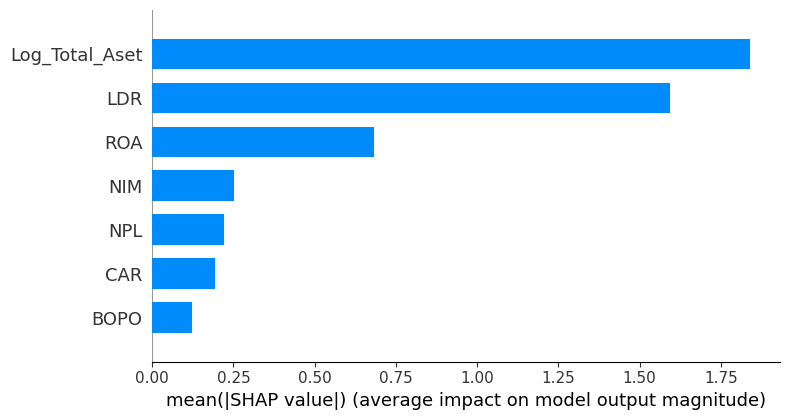

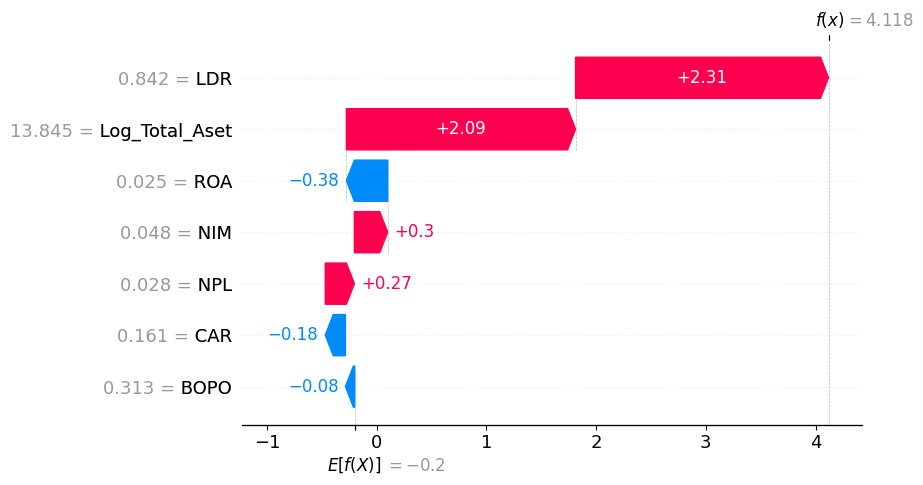

In [ ]:
imputer_B = xgb_pipeline_B.named_steps["imputer"]
xgb_model_B = xgb_pipeline_B.named_steps["model"]

X_test_imp_B = imputer_B.transform(X_test_B)

explainer_B = shap.TreeExplainer(xgb_model_B)
shap_values_B = explainer_B.shap_values(X_test_imp_B)

shap.summary_plot(
    shap_values_B,
    X_test_imp_B,
    feature_names=feature_cols_B
)

shap.summary_plot(
    shap_values_B,
    X_test_imp_B,
    feature_names=feature_cols_B,
    plot_type="bar"
)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_B[0],
        base_values=explainer_B.expected_value,
        data=X_test_imp_B[0],
        feature_names=feature_cols_B
    )
)

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_scores_xgb = cross_val_score(xgb_pipeline, X, y, cv=skf, scoring='f1')

print(f"XGBoost (Full Features) Cross-Validation F1 Scores: {f1_scores_xgb}")
print(f"Mean F1 Score (Full Features): {f1_scores_xgb.mean():.4f}")
print(f"Std Dev F1 Score (Full Features): {f1_scores_xgb.std():.4f}")

print("\n" + "="*50 + "\n")

skf_B = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_scores_xgb_B = cross_val_score(xgb_pipeline_B, X_B, y_B, cv=skf_B, scoring='f1')

print(f"XGBoost (Reduced Features) Cross-Validation F1 Scores: {f1_scores_xgb_B}")
print(f"Mean F1 Score (Reduced Features): {f1_scores_xgb_B.mean():.4f}")
print(f"Std Dev F1 Score (Reduced Features): {f1_scores_xgb_B.std():.4f}")

XGBoost (Full Features) Cross-Validation F1 Scores: [0.97297297 0.97142857 0.94444444 0.94117647 0.90909091]
Mean F1 Score (Full Features): 0.9478
Std Dev F1 Score (Full Features): 0.0234


XGBoost (Reduced Features) Cross-Validation F1 Scores: [0.97297297 0.97142857 0.94444444 0.94117647 0.90909091]
Mean F1 Score (Reduced Features): 0.9478
Std Dev F1 Score (Reduced Features): 0.0234
